In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("hospital_patient_flow.csv")
df.head()

,patient_id,age,gender,state_of_origin,department,diagnosis,admission_date,admission_time,discharge_date,length_of_stay_days,outcome,insurance_type,total_bill_ngn,amount_paid_ngn,attending_doctor_id,ward,readmitted
0,PAT-200000,62,Male,Benin City,Orthopedics,Hypertension,2023-02-19,00:00,2023-02-19,0,Still Admitted,Corporate,90000.0,509100.0,DR-066,Ward 9,No
1,PAT-200001,21,Female,Port Harcourt,General Medicine,Kidney Disease,2022-10-27,02:00,2022-11-15,19,Referred,NHIS,455000.0,24000.0,DR-014,Ward 19,No
2,PAT-200002,79,Female,Abuja,Neurology,Hypertension,2022-04-21,06:00,2022-04-27,6,Discharged,NaN,575000.0,265200.0,DR-050,Ward 4,No
3,PAT-200003,16,Male,Lagos,General Medicine,Fracture,2022-06-01,00:00,2022-06-07,6,Still Admitted,NaN,57000.0,585000.0,DR-026,Ward 19,No
4,PAT-200004,47,Female,Lagos,Pediatrics,HIV/AIDS,2021-04-26,21:00,2021-05-20,24,Still Admitted,NHIS,675000.0,128700.0,DR-063,Ward 12,No


In [3]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (60000, 17)

Data Types:
patient_id                 str
age                      int64
gender                     str
state_of_origin            str
department                 str
diagnosis                  str
admission_date             str
admission_time             str
discharge_date             str
length_of_stay_days      int64
outcome                    str
insurance_type             str
total_bill_ngn         float64
amount_paid_ngn        float64
attending_doctor_id        str
ward                       str
readmitted                 str
dtype: object

Missing Values:
patient_id                 0
age                        0
gender                     0
state_of_origin            0
department                 0
diagnosis                  0
admission_date             0
admission_time             0
discharge_date             0
length_of_stay_days        0
outcome                    0
insurance_type         12122
total_bill_ngn             0
amount_paid_ngn            0
atte

In [4]:
# Convert dates
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

# Create bill gap
df['bill_gap'] = df['total_bill_ngn'] - df['amount_paid_ngn']

In [5]:
df[['total_bill_ngn','amount_paid_ngn','bill_gap']].head()

,total_bill_ngn,amount_paid_ngn,bill_gap
0,90000.0,509100.0,-419100.0
1,455000.0,24000.0,431000.0
2,575000.0,265200.0,309800.0
3,57000.0,585000.0,-528000.0
4,675000.0,128700.0,546300.0


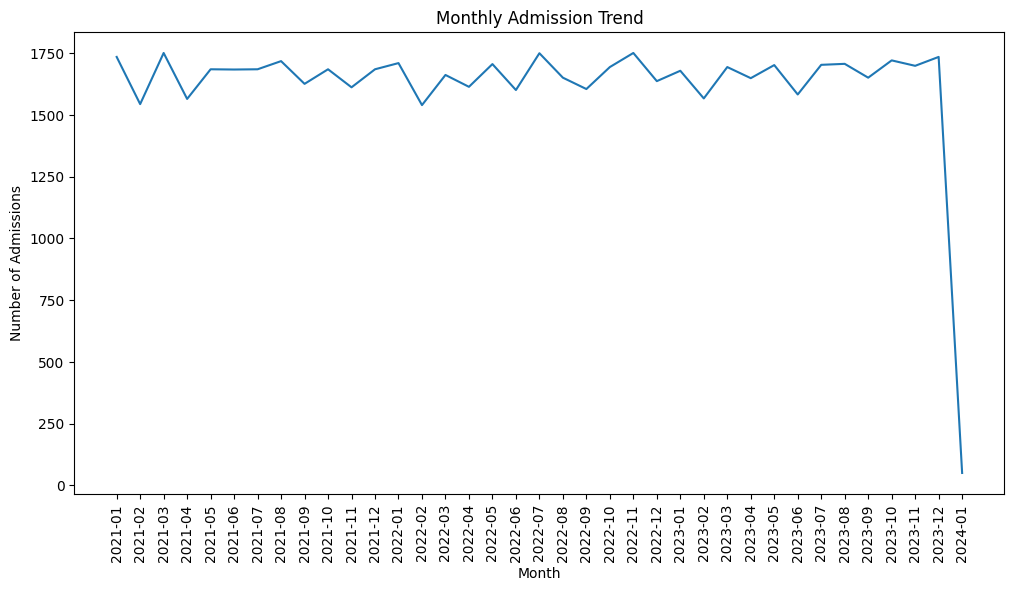

In [6]:
monthly_admissions = (
    df.groupby(df['admission_date'].dt.to_period('M'))
      .size()
      .reset_index(name='admissions')
)

monthly_admissions['admission_date'] = (
    monthly_admissions['admission_date'].astype(str)
)

plt.figure(figsize=(12,6))

plt.plot(
    monthly_admissions['admission_date'],
    monthly_admissions['admissions']
)

plt.title('Monthly Admission Trend')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=90)

plt.show()

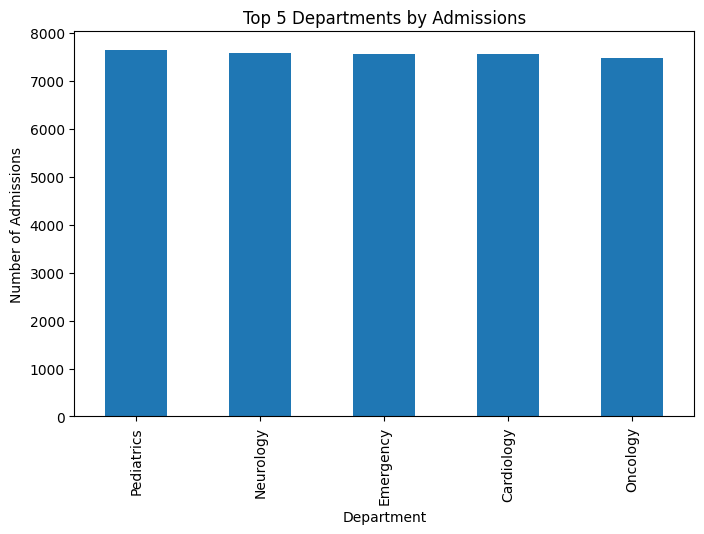

In [7]:
top_departments = (
    df['department']
    .value_counts()
    .head(5)
)

plt.figure(figsize=(8,5))

top_departments.plot(kind='bar')

plt.title('Top 5 Departments by Admissions')
plt.xlabel('Department')
plt.ylabel('Number of Admissions')

plt.show()

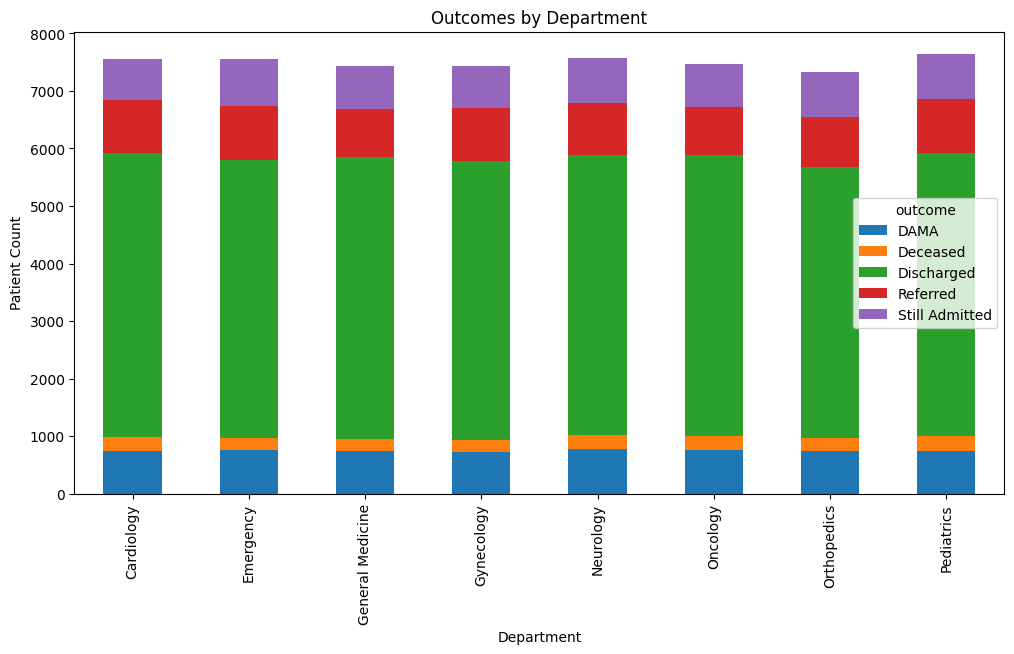

In [8]:
outcome_department = pd.crosstab(
    df['department'],
    df['outcome']
)

outcome_department.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Outcomes by Department')
plt.xlabel('Department')
plt.ylabel('Patient Count')

plt.show()

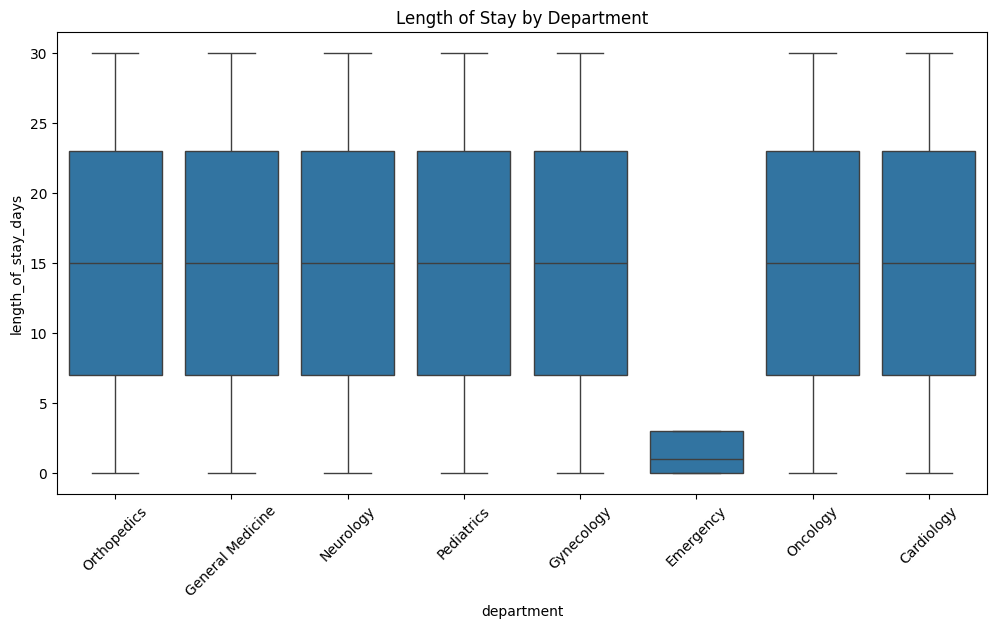

In [9]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='department',
    y='length_of_stay_days'
)

plt.xticks(rotation=45)

plt.title('Length of Stay by Department')

plt.show()

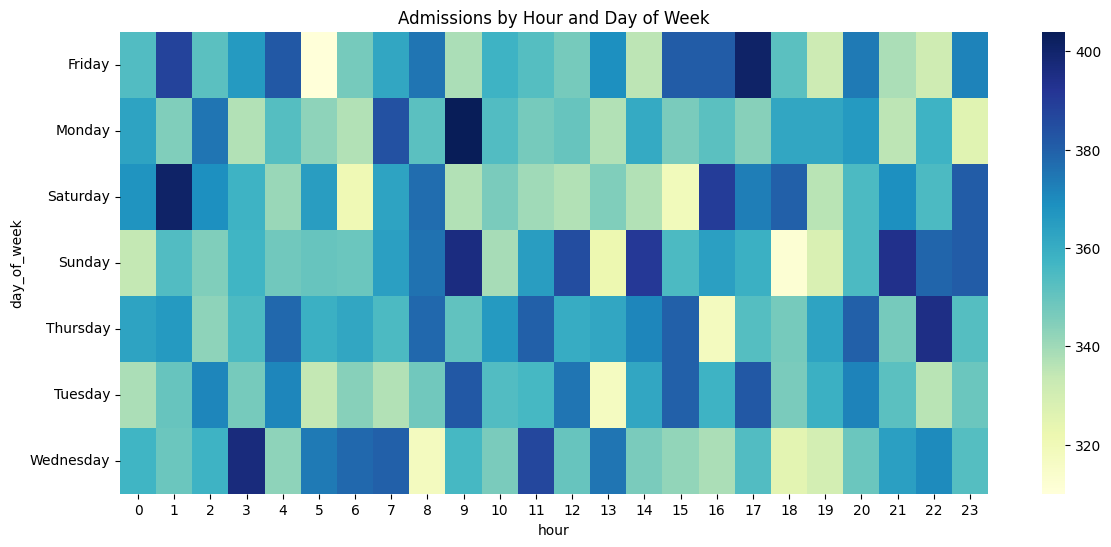

In [10]:
df['day_of_week'] = df['admission_date'].dt.day_name()
df['hour'] = pd.to_datetime(
    df['admission_time'],
    format='%H:%M'
).dt.hour
heatmap_data = pd.crosstab(
    df['day_of_week'],
    df['hour']
)

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap='YlGnBu'
)

plt.title('Admissions by Hour and Day of Week')

plt.show()

In [11]:
df['insurance_type'] = df['insurance_type'].fillna('Unknown')


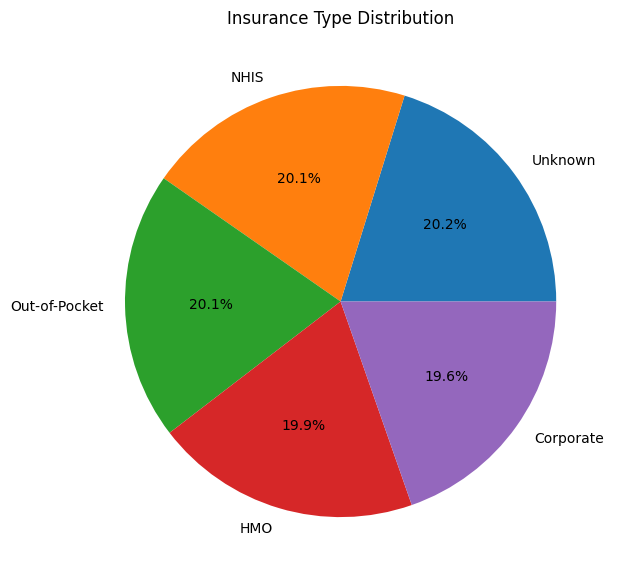

In [12]:
insurance_counts = df['insurance_type'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    insurance_counts,
    labels=insurance_counts.index,
    autopct='%1.1f%%'
)

plt.title('Insurance Type Distribution')

plt.show()

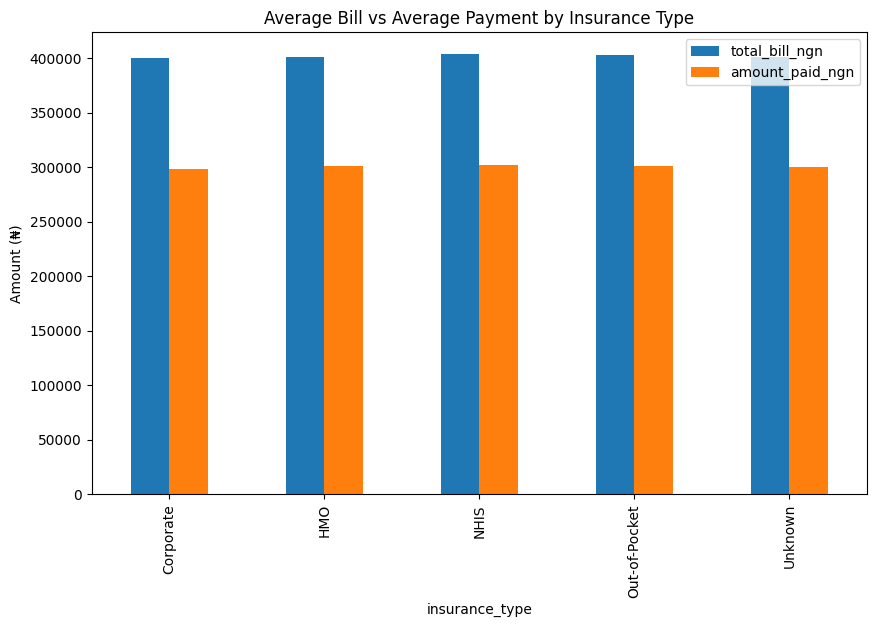

In [13]:
insurance_summary = (
    df.groupby('insurance_type')
    [['total_bill_ngn','amount_paid_ngn']]
    .mean()
)

insurance_summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Bill vs Average Payment by Insurance Type')
plt.ylabel('Amount (₦)')

plt.show()

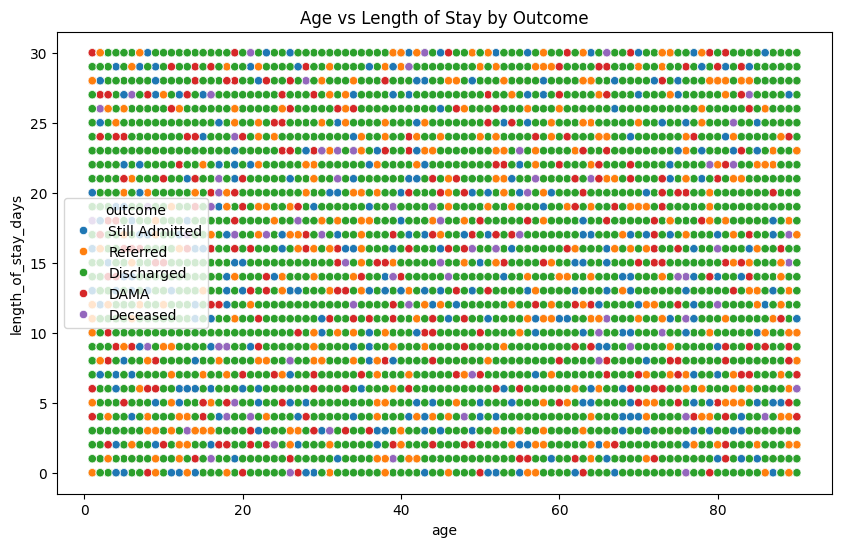

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='age',
    y='length_of_stay_days',
    hue='outcome'
)

plt.title('Age vs Length of Stay by Outcome')

plt.show()

## Operational Insights

1. Monthly admissions remained relatively stable throughout the analysis period, indicating consistent patient inflow across the hospital.

2. Most patient outcomes resulted in successful discharge, while deceased and DAMA cases represented a relatively small proportion of admissions.

3. Emergency department patients experienced shorter lengths of stay compared to other departments, reflecting the urgent nature of emergency care.

4. Average hospital bills consistently exceeded average amounts paid across all insurance types, suggesting the existence of outstanding balances and revenue gaps.

5. Insurance utilization was evenly distributed among NHIS, HMO, Corporate, Out-of-Pocket, and Unknown categories, indicating a diverse patient payment mix.